## PART III:  Error analysis Bootstrap method

In [2]:
import sys,os
import numpy as np
import scipy
from scipy.integrate import quad
from scipy.stats import kde
from scipy.stats import chi2 as spchi2
from scipy.optimize import minimize,leastsq
import matplotlib
import matplotlib.pyplot as py
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
rc('text', usetex=True)  
%matplotlib inline  
%config InlineBackend.figure_format = 'retina'
from tools import tex,save, load,fill_between,plot_hist,ProgressBar
from tools import EVENTS,VEC4
import numpy.linalg as LA 
from scipy.interpolate import interp1d
from scipy.optimize import fsolve,brentq,newton,fmin
from numpy.random import randn

# The signal + background

Get data

In [3]:
path='samples/sb.lhe.gz'
sb=EVENTS(path)
sb.D['m']=[]
for i in range(sb.nevents):
    particles=sb.EVENTS[i]
    for p in particles:
        if p['pid']==-13: mub=p['mom']
        elif p['pid']==13: mu=p['mom']
    z=mu+mub
    sb.D['m'].append((z*z)**0.5) 

construct observable

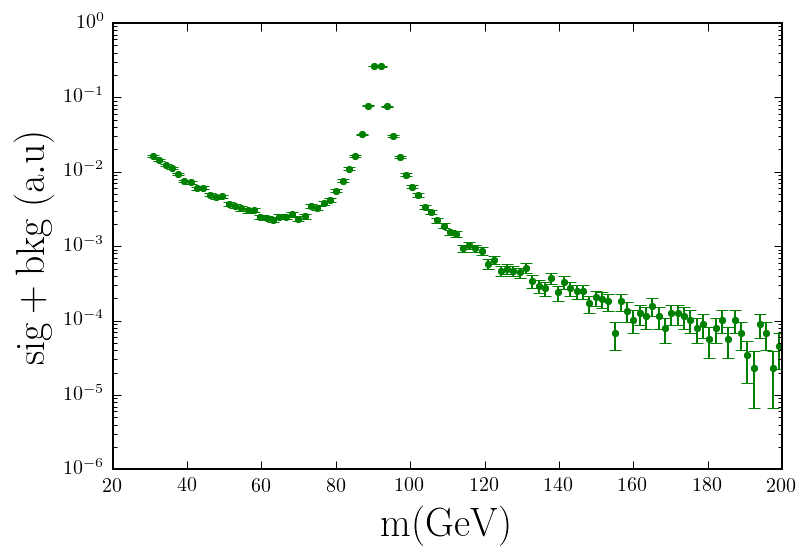

In [64]:
N,E=np.histogram(sb.D['m'],bins=100,range=(30,200))

M=0.5*(E[:-1]+E[1:])
NTOT=np.sum(N)
OBS=N/float(NTOT)
ERR=N/float(NTOT)*(np.sqrt(N)/N+np.sqrt(NTOT)/float(NTOT))

ax=py.subplot(111)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

Define model

In [65]:
rs=1300.0

model_sig = lambda p,m: p[0]*m**2 /((m**2-p[1]**2)**2+m**2 *p[2]**2)*(1+p[3]*(m/rs) + p[4]*(m/rs)**2)
model_bkg = lambda p,m: p[5]/m**(p[6])*(1+p[7]*(m/rs))
params_input = [1,91,1,1,1,1,1,1]

# model_sig = lambda p,m: p[0]*m**2 /((m**2-p[1]**2)**2+m**2 *p[2]**2)
# model_bkg = lambda p,m: p[3]/m**4 * (1+p[4]*(m/rs))
# params_input = [1,91,1,1,1]

# model_sig = lambda p,m: p[0]/((m**2-p[1]**2)**2+m**2 *p[2]**2)*(1+p[3]*(m/rs) + p[4]*(m/rs)**2)
# model_bkg = lambda p,m: p[5]/m**(4+p[6])*(1+p[7]*(m/rs))
# params_input = [1,91.0,1,1,1,1,1,1]

model_sb  = lambda p,m: model_sig(p,m) + model_bkg(p,m)

Perform single fit 

p0 = 7.657372
p1 = 91.205995
p2 = 2.482069
p3 = -13.320192
p4 = 49.871674
p5 = 437.082652
p6 = 2.920731
p7 = -5.899283
chi^2/dof= 1.13486719641


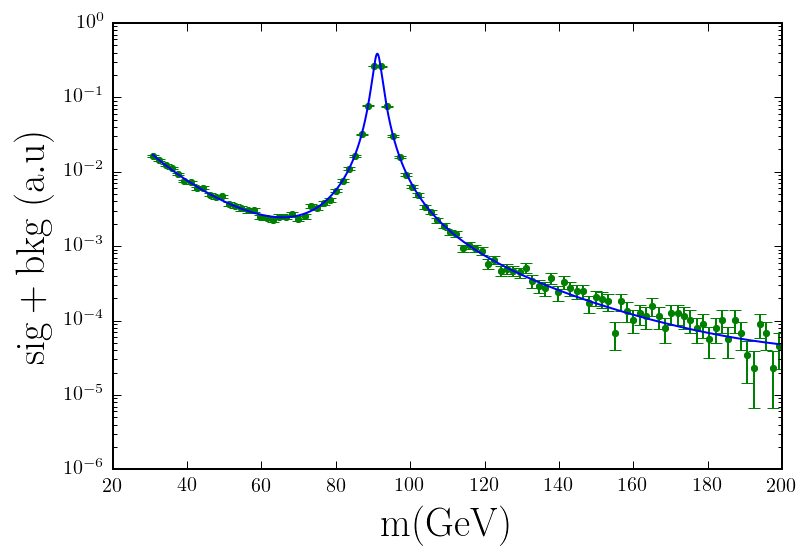

In [66]:
# single fit
res=lambda p,OBS: (OBS-model_sb(p,M))/ERR
p0=leastsq(res,params_input,args=(OBS),full_output=1)[0]
res0 = res(p0,OBS)
chi2sb  = np.dot(res0,res0)
chi2dof = chi2sb/(OBS.size-p0.size)
for i in range(p0.size): print 'p%d = %f'%(i,p0[i])
print 'chi^2/dof=',chi2dof
ax=py.subplot(111)
ax.errorbar(M,OBS,yerr=ERR,fmt='g.')

Mmin=np.amin(M)
Mmax=np.amax(M)
M_=np.linspace(Mmin,Mmax,1000)
ax.plot(M_,model_sb(p0,M_),'b-')
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)
ax.semilogy();

MC fits

[**************************100%********]  computing MC fits   500 of 500 complete

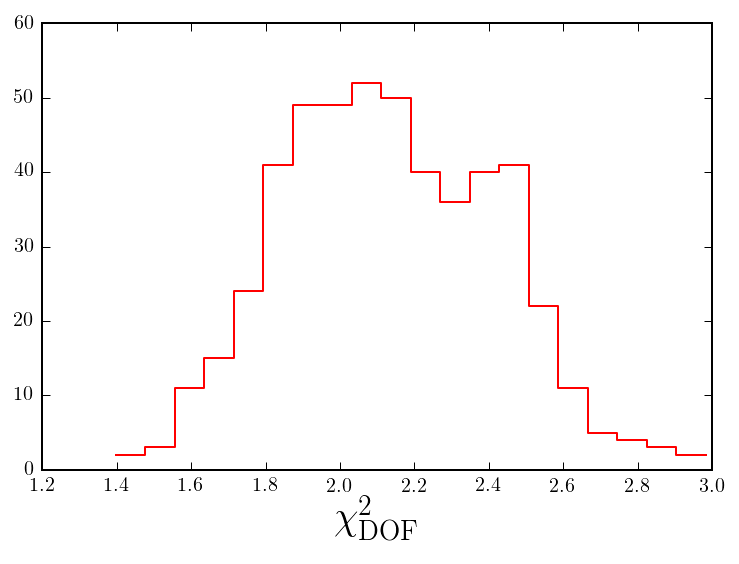

In [67]:
# MC fit
nrep=500
bar=ProgressBar(nrep,'computing MC fits ')
POPT=[]
REP=[]
CHI2=[]
for i in range(nrep):
    bar.animate(i+1)
    OBSk=OBS + randn(OBS.size)*ERR
    fit=leastsq(res,p0,args=(OBSk),full_output=1)
    resk=res(fit[0],OBSk)
    CHI2.append(np.dot(resk,resk)/(OBS.size-p0.size))
    POPT.append(fit[0])
    REP.append(OBSk)
    
ax=py.subplot(111)
N,E=np.histogram(CHI2,bins=20)
plot_hist(ax,'r',E,N,symbol='-')
ax.set_xlabel(tex('\chi^2_{DOF}'),size=20)

MC parameters 

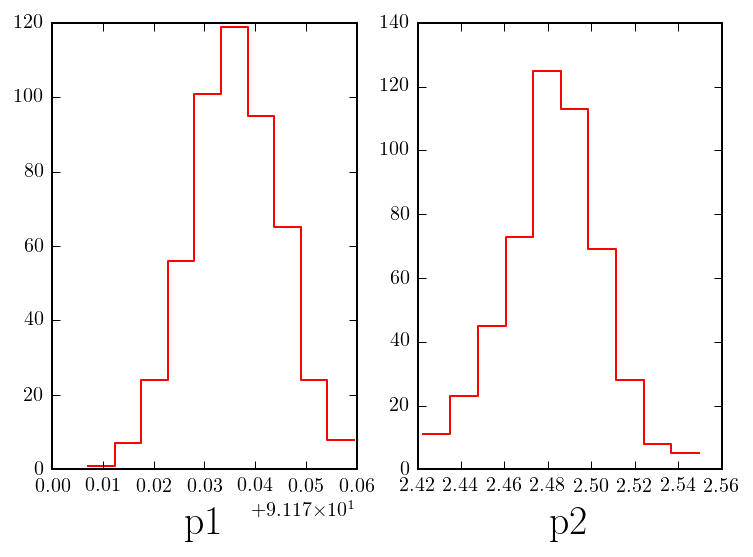

In [68]:
ax=py.subplot(121)
N,E=np.histogram([popt[1] for popt in POPT])
plot_hist(ax,'r',E,N,symbol='-')
ax.set_xlabel(tex('p1'),size=20)

ax=py.subplot(122)
N,E=np.histogram([popt[2] for popt in POPT])
plot_hist(ax,'r',E,N,symbol='-')
ax.set_xlabel(tex('p2'),size=20)

plot results

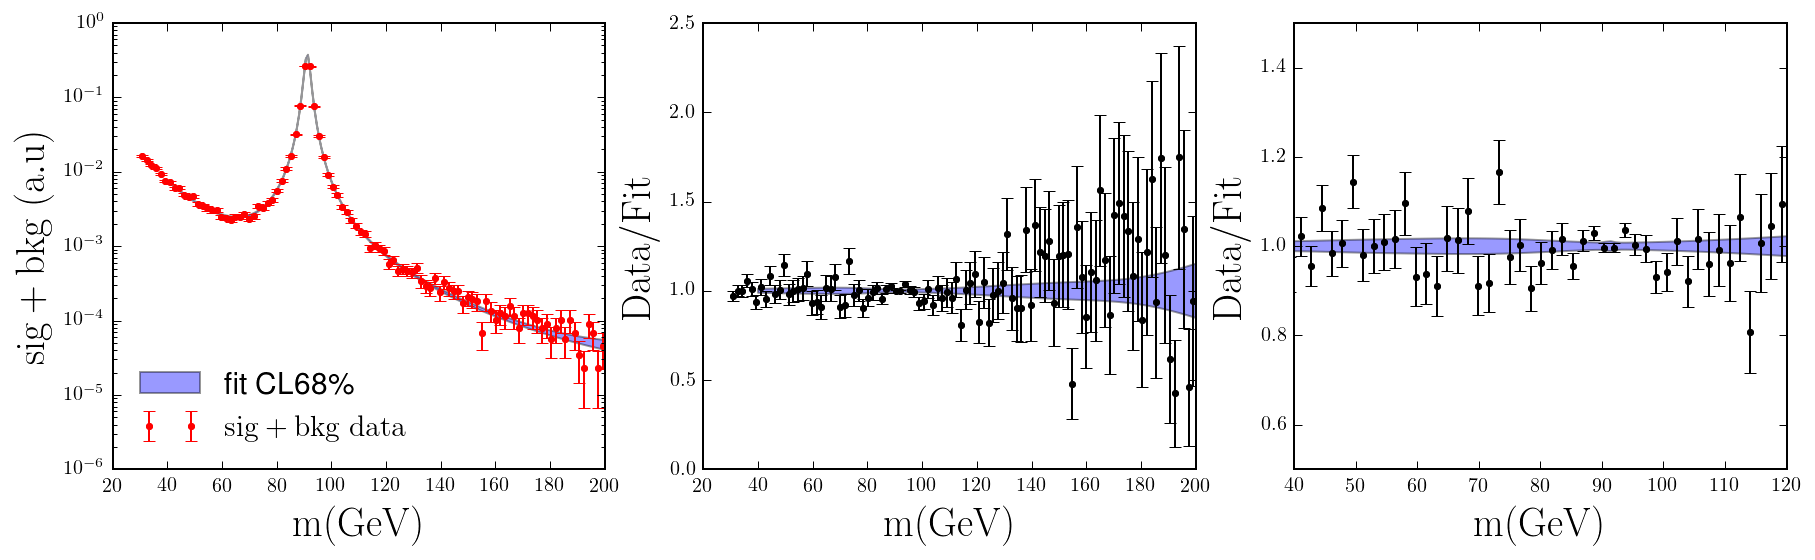

In [69]:
M0=np.linspace(40,200,200)
OBSK=np.zeros((len(POPT),len(M0)))
for k in range(nrep): OBSK[k]=model_sb(POPT[k],M0)
OBS0=model_sb(p0,M0)
std=np.std(OBSK,axis=0)
OBSMAX=OBS0+std
OBSMIN=OBS0-std

py.figure(figsize=(5*3,4*1))

ax=py.subplot(131)
ax.errorbar(M,OBS,yerr=ERR,fmt='r.',label=tex('sig+bkg~data'))
fill_between(M0,y1=OBSMIN,y2=OBSMAX, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.semilogy()
ax.legend(fontsize=15,frameon=0,loc=3)
ax.set_ylabel(tex(r'sig+bkg~(a.u)'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

ax=py.subplot(132)
fill_between(M0,y1=OBSMIN/OBS0,y2=OBSMAX/OBS0, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.errorbar(M,OBS/model_sb(p0,M),yerr=ERR/model_sb(p0,M),fmt='k.')
ax.set_ylabel(tex(r'Data/Fit'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)

ax=py.subplot(133)
fill_between(M0,y1=OBSMIN/OBS0,y2=OBSMAX/OBS0, ax=ax, facecolor='b',alpha=0.4,label='fit~CL68\%')
ax.errorbar(M,OBS/model_sb(p0,M),yerr=ERR/model_sb(p0,M),fmt='k.')
ax.set_xlim(40,120)
ax.set_ylim(0.5,1.5);
ax.set_ylabel(tex(r'Data/Fit'),size=20)
ax.set_xlabel(tex(r'm (GeV)'),size=20)